# 🧪 Lab 2: Modelling & Model Lifecycle : Predicting Plant Production (GIST Steel Dataset)

---

## 🎯 Learning Outcomes

By completing this lab, you will be able to:

- Prepare and analyse a dataset for modelling, including a schema check before cleaning.  
- Train and evaluate regression models.  
- Apply cross-validation and hyperparameter tuning using scikit-learn.  
- Track experiments and store models using MLflow and/or Optuna.  
- Reflect on the practical aspects of managing the ML lifecycle.

---


### Completed analysis: scope and reproducibility

Source: Global Energy Monitor, **Global Iron and Steel Tracker, June 2026 V1**, the local workbook supplied with Lab 1. The unchanged workbook is included in `data/gist_june_2026.xlsx`. Source documentation: [GIST methodology](https://globalenergymonitor.org/projects/global-iron-steel-tracker/), plus the workbook's About and Metadata sheets.

Target: **2024 crude steel production**, in thousands of metric tonnes (the workbook describes calendar 2024 / fiscal 2025). Predictors are a **June 2026 snapshot**. This is a retrospective cross-sectional exercise, not an advance forecast of 2024. A real forecasting evaluation requires dated predictors available before the outcome year and a later-year holdout.

The train/test split, five CV folds, and random seeds are fixed. Selection uses training-only CV. Test scores are displayed where the lab requests them, but never used to choose features, models or tuning parameters. Optional TabFM is not included in the classical selection procedure.


## Submission details

| Member | Full name | Student ID |
|---|---|---|
| 1 | Adam Zeraiki | B00819260 |
| 2 | Lina Oumhand | B00820945 |
| 3 | Chris William Karam | B00825083 |
| 4 | Liam Szefner | B00822121 |

**Group / repo name:** `aidams-lab2-zeraiki-oumhand-karam-szefner`  
**Submitter:** Adam Zeraiki  
**Repo URL:** https://github.com/Azzbee/aidams-lab2-zeraiki-oumhand-karam-szefner

Repository visibility is public at the submitter's request. The original lab requested a private repository. The submission email is prepared separately for Adam to send.


## 🧩 1. Data Setup and Exploration

### 🧭 Objective
Understand the dataset structure and the target variable (“plant-level production”).

---

### **Task 1.1 - Load and Inspect Data**
- Load the [GIST Steel dataset](https://globalenergymonitor.org/projects/global-iron-steel-tracker) using [pandas](https://pandas.pydata.org/) (bonus: using [polars](https://pola.rs/).)
- Work at **plant level**: one row per plant. 
- Display basic info (shape, column names, missing values, and data types).
- Identify the target variable (production) and key features (capacity, ...).

Column names differ by release. Inspect `df.columns` and adapt the schema and features to the file you downloaded. [skrub](https://skrub-data.org/)’s `TableReport` is optional here; the modelling use of skrub is in Task 2.1.

In [1]:
import hashlib
import importlib.metadata
import json
import math
import os
import platform
import subprocess
import warnings
from collections.abc import Sequence
from datetime import datetime, timezone
from pathlib import Path
from typing import cast

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pandera.pandas as pa
import seaborn as sns
from IPython.display import Markdown, display
from numpy.typing import NDArray
from sklearn.base import BaseEstimator, clone
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_absolute_error, r2_score, root_mean_squared_error
from sklearn.model_selection import (
    KFold,
    RandomizedSearchCV,
    cross_validate,
    train_test_split,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, OneHotEncoder, StandardScaler

from lab_utils import (
    BASE_NUMERIC,
    CATEGORICAL,
    ENGINEERED,
    FEATURES,
    engineer_features,
    input_schema,
    predict_batch,
)

SEED = 42
BASE = Path.cwd()
DATA = BASE / "data/gist_june_2026.xlsx"
ARTIFACTS = BASE / "artifacts"
ARTIFACTS.mkdir(exist_ok=True)
assert DATA.exists(), "Run this notebook from the lab_2_complete folder."
DATA_SHA256 = hashlib.sha256(DATA.read_bytes()).hexdigest()
print("Dataset SHA-256:", DATA_SHA256)
pd.set_option("display.max_columns", 30)
sns.set_theme(style="whitegrid")
# Expected with fold-specific rare categories; report unseen test levels explicitly below.
warnings.filterwarnings(
    "ignore",
    message="Found unknown categories.*",
    category=UserWarning,
    module="sklearn.preprocessing._encoders",
)

# Preserve source sentinels so the raw schema check sees them before cleaning.
sheets = pd.read_excel(DATA, sheet_name=None, keep_default_na=False)
plants = sheets["Plant data"]
capacities = sheets["Plant capacities and status"]
production = sheets["Plant production"]
ID = "GEM plant ID"
TARGET_YEAR = 2024
CAPACITY_COLUMNS = [
    "Nominal crude steel capacity (ttpa)",
    "Nominal iron capacity (ttpa)",
    "Nominal EAF steel capacity (ttpa)",
]
ACTIVE_STATUSES = ["operating", "operating pre-retirement"]
for sheet_name, table in sheets.items():
    print(sheet_name, table.shape)
print("Plant columns:", plants.columns.tolist())
print("Capacity columns:", capacities.columns.tolist())
print("Production columns:", production.columns.tolist())

crude = production.loc[
    production["Type of production"].eq("Crude steel production (ttpa)")
].copy()
year_columns = [c for c in crude.columns if isinstance(c, int)]
coverage = pd.DataFrame(
    {
        "year": year_columns,
        "numeric_labels_before_dedup": [
            pd.to_numeric(crude[c], errors="coerce").notna().sum() for c in year_columns
        ],
    }
)
display(coverage)
print("Duplicate crude-production IDs:", int(crude.duplicated(ID).sum()))
display(
    crude.loc[
        crude.duplicated(ID, keep=False), [ID, "Plant name (English)", TARGET_YEAR]
    ]
)
# Structural deduplication only: the selected year's duplicate values must agree.
assert crude.groupby(ID)[TARGET_YEAR].nunique(dropna=False).le(1).all()
target_rows = (
    crude[[ID, TARGET_YEAR]]
    .drop_duplicates()
    .rename(columns={TARGET_YEAR: "production_2024_ttpa"})
)
assert target_rows[ID].is_unique
assert plants[ID].is_unique
assert not capacities.duplicated([ID, "Status"]).any()

# Pivot without numeric conversion or aggregation. This preserves raw errors.
active_rows = capacities[capacities["Status"].isin(ACTIVE_STATUSES)]
raw_capacity = active_rows.pivot(index=ID, columns="Status", values=CAPACITY_COLUMNS)
raw_capacity.columns = [
    f"{col} [{status}]"
    for col, status in cast(list[tuple[str, str]], raw_capacity.columns.to_list())
]
raw_capacity_columns = raw_capacity.columns.tolist()
raw_status = capacities.groupby(ID)["Status"].agg(
    lambda values: "; ".join(sorted(set(values)))
)
df = (
    plants.merge(raw_capacity, on=ID, how="left", validate="one_to_one")
    .merge(target_rows, on=ID, how="left", validate="one_to_one")
    .merge(
        raw_status.rename("Capacity statuses"), on=ID, how="left", validate="one_to_one"
    )
)
print("Raw plant-level shape:", df.shape)
assert len(df) == len(plants) and df[ID].is_unique
print("Joined columns:", df.columns.tolist())
df.info()
inspection = pd.DataFrame(
    {
        "dtype": df.dtypes.astype(str),
        "nulls": df.isna().sum(),
        "source_unknown_or_blank": df.apply(
            lambda column: column.astype(str).str.lower().isin(["unknown", ""]).sum()
        ),
        "source_N/A": df.apply(lambda column: column.astype(str).eq("N/A").sum()),
    }
)
display(inspection)
display(
    df[
        [
            ID,
            "Plant name (English)",
            "Country/area",
            "Workforce size",
            "production_2024_ttpa",
        ]
    ].head()
)

Dataset SHA-256: a5768b59cd7e6cec217692ae45eda80ea70aab1666aef74332cc1b41dd5338eb


About (60, 3)
Metadata (79, 2)
Plant data (1293, 44)
Plant capacities and status (1845, 16)
Plant production (1393, 10)
Plant columns: ['GEM plant ID', 'Plant name (English)', 'Plant name (other language)', 'Other plant names (English)', 'Other plant names (other language)', 'Owner', 'Owner (other language)', 'Owner GEM entity ID', 'Owner PermID', 'SOE status', 'Parent (English)', 'Parent GEM entity ID', 'Parent PermID', 'Location address', 'Location address (other language)', 'Municipality', 'Subnational unit', 'Country/area', 'Region', 'Coordinates', 'Coordinate accuracy', 'GEM wiki page', 'Plant age', 'Announced date', 'Construction date', 'Start date', 'Pre-retirement announcement date', 'Idled date', 'Retired date', 'Ferronickel capacity (ttpa)', 'Sinter plant capacity (ttpa)', 'Coking plant capacity (ttpa)', 'Pelletizing plant capacity (ttpa)', 'Category steel product', 'Steel products', 'Steel sector end users', 'Workforce size', 'ISO 14001', 'ISO 50001', 'ResponsibleSteel certi

,year,numeric_labels_before_dedup
0,2019,204
1,2020,243
2,2021,258
3,2022,261
4,2023,273
5,2024,257
6,2025,5


Duplicate crude-production IDs: 7


,GEM plant ID,Plant name (English),2024
1335,P100000120673,Yamato Steel Himeji Plant,unknown
1337,P100000120310,Yancheng Lianxin Iron and Steel Co Ltd,unknown
1339,P100000120912,Yenakiieve Metallurgical Plant,unknown
1344,P100000120900,Yieh United Steel Kaohsiung plant,unknown
1346,P100000120703,YK Steel Busan plant,unknown
1349,P100000120300,Yunnan Yuxi Iron and Steel Group Yukun Iron an...,unknown
1355,P100000120129,Zhongpu Handan Iron and Steel Co Ltd,unknown
1365,P100000120673,Yamato Steel Himeji Plant,unknown
1367,P100000120310,Yancheng Lianxin Iron and Steel Co Ltd,unknown
1373,P100000120912,Yenakiieve Metallurgical Plant,unknown


Raw plant-level shape: (1293, 52)
Joined columns: ['GEM plant ID', 'Plant name (English)', 'Plant name (other language)', 'Other plant names (English)', 'Other plant names (other language)', 'Owner', 'Owner (other language)', 'Owner GEM entity ID', 'Owner PermID', 'SOE status', 'Parent (English)', 'Parent GEM entity ID', 'Parent PermID', 'Location address', 'Location address (other language)', 'Municipality', 'Subnational unit', 'Country/area', 'Region', 'Coordinates', 'Coordinate accuracy', 'GEM wiki page', 'Plant age', 'Announced date', 'Construction date', 'Start date', 'Pre-retirement announcement date', 'Idled date', 'Retired date', 'Ferronickel capacity (ttpa)', 'Sinter plant capacity (ttpa)', 'Coking plant capacity (ttpa)', 'Pelletizing plant capacity (ttpa)', 'Category steel product', 'Steel products', 'Steel sector end users', 'Workforce size', 'ISO 14001', 'ISO 50001', 'ResponsibleSteel certification', 'Main production equipment', 'Power source', 'Iron ore source', 'Met coal 

,dtype,nulls,source_unknown_or_blank,source_N/A
GEM plant ID,str,0,0,0
Plant name (English),str,0,0,0
Plant name (other language),str,0,502,0
Other plant names (English),str,0,551,0
Other plant names (other language),str,0,958,0
Owner,str,0,2,0
Owner (other language),str,0,715,0
Owner GEM entity ID,str,0,0,0
Owner PermID,object,0,551,0
SOE status,str,0,0,1081


,GEM plant ID,Plant name (English),Country/area,Workforce size,production_2024_ttpa
0,P100000120882,Aba Iron and Steel Payas plant,Türkiye,900,NaN
1,P100000120753,Abba Steel Ohangwena steel plant,Namibia,5500,NaN
2,P100000120802,Abinsk Electric Steel Works,Russia,4500,unknown
3,P100000120020,Abul Khair Steel Sitakunda plant,Bangladesh,unknown,NaN
4,P100000120620,Acciaierie d'Italia Taranto steel plant,Italy,11000,2000


> 📝 *Critical thinking:*
> Describe any patterns or potential data quality issues you notice. Which variables might strongly influence production?


**Answer**

The workbook has three different row grains: one plant, one plant/status, and one plant/production type. Joining them directly would duplicate plants and overweight their outcomes. The raw pivot keeps the two active capacity statuses separate until validation. For 2024, duplicate target rows contain the same value, so retaining one copy is safe. Total crude production already includes its technology routes; adding EAF or BOF production would double count output.

Missingness includes literal `unknown`, `N/A`, blank cells and absent joined records. These are not interchangeable. Capacity, workforce, equipment and plant age are plausible predictors, but capacity and age are measured in 2026. Reporting availability may also differ by country and company, so labelled plants may not represent the entire population.

### **Task 1.2 - Schema Check with Pandera**
After Task 1.1, and before any cleaning, write a [Pandera](https://pandera.readthedocs.io/) `DataFrameSchema` for the columns you will use.
- Check dtypes and required columns, including the target.
- Add a few value checks that match what you saw in the file (for example capacity ≥ 0, or status limited to the categories present in the data). Column names vary by GIST release, so build the schema from `df.columns`, not from a guessed list.
- Run `schema.validate(df)` and show what fails.

Use the result in Task 1.3: drop, coerce, or relax a check, and say which.

In [2]:
# Deliberately strict analytical schema: validate before numeric cleaning.
# Names below have just been inspected and are asserted present, not guessed.
raw_numeric = raw_capacity_columns + [
    "Workforce size",
    "Plant age",
    "production_2024_ttpa",
]
assert set(
    raw_numeric + [ID, "Country/area", "Main production equipment", "Capacity statuses"]
).issubset(df.columns)
observed_statuses = set(capacities["Status"].unique())
raw_columns = {
    name: pa.Column(float, pa.Check.ge(0), nullable=(name != "production_2024_ttpa"))
    for name in raw_numeric
}
raw_columns.update(
    {
        ID: pa.Column(str, unique=True, nullable=False),
        "Country/area": pa.Column(str, nullable=False),
        "Main production equipment": pa.Column(str, nullable=False),
        "Capacity statuses": pa.Column(
            str,
            pa.Check.isin(df["Capacity statuses"].unique().tolist()),
        ),
    }
)
schema = pa.DataFrameSchema(raw_columns, strict=False, coerce=False)
try:
    schema.validate(df, lazy=True)
    raw_failures = pd.DataFrame()
    print("Raw schema passed.")
except pa.errors.SchemaErrors as exc:
    raw_failures = exc.failure_cases
    print(
        "Raw schema failed as expected:", len(raw_failures), "reported failure records"
    )
    display(raw_failures.head(25))
    display(
        raw_failures.groupby(["column", "check"], dropna=False)
        .size()
        .rename("failures")
        .to_frame()
    )
raw_failures.to_csv(ARTIFACTS / "raw_schema_failures.csv", index=False)
schema.to_yaml(ARTIFACTS / "raw_schema.yaml")

Raw schema failed as expected: 2500 reported failure records


,schema_context,column,check,check_number,failure_case,index
0,Column,Nominal crude steel capacity (ttpa) [operating],dtype('float64'),None,N/A,14
1,Column,Nominal crude steel capacity (ttpa) [operating],dtype('float64'),None,N/A,20
2,Column,Nominal crude steel capacity (ttpa) [operating],dtype('float64'),None,N/A,59
3,Column,Nominal crude steel capacity (ttpa) [operating],dtype('float64'),None,N/A,103
4,Column,Nominal crude steel capacity (ttpa) [operating],dtype('float64'),None,N/A,107
5,Column,Nominal crude steel capacity (ttpa) [operating],dtype('float64'),None,N/A,118
6,Column,Nominal crude steel capacity (ttpa) [operating],dtype('float64'),None,N/A,183
7,Column,Nominal crude steel capacity (ttpa) [operating],dtype('float64'),None,N/A,219
8,Column,Nominal crude steel capacity (ttpa) [operating],dtype('float64'),None,N/A,231
9,Column,Nominal crude steel capacity (ttpa) [operating],dtype('float64'),None,N/A,236


failures
column                                             check                                
Nominal EAF steel capacity (ttpa) [operating pr... dtype('float64')                   76
                                                   greater_than_or_equal_to(0)         1
Nominal EAF steel capacity (ttpa) [operating]      dtype('float64')                  363
                                                   greater_than_or_equal_to(0)         1
Nominal crude steel capacity (ttpa) [operating ... dtype('float64')                   26
                                                   greater_than_or_equal_to(0)         1
Nominal crude steel capacity (ttpa) [operating]    dtype('float64')                   59
                                                   greater_than_or_equal_to(0)         1
Nominal iron capacity (ttpa) [operating pre-ret... dtype('float64')                   39
                                                   greater_than_or_equal_to(0)         1
Nominal iron capacity (ttpa) [operating]           dtype('float64')                  467
                                                   greater_than_or_equal_to(0)         1
Plant age                                          dtype('float64')                  168
                                                   greater_than_or_equal_to(0)         1
Workforce size                                     dtype('float64')                  257
                                                   greater_than_or_equal_to(0)         1
production_2024_ttpa                               dtype('float64')                  167
                                                   greater_than_or_equal_to(0)         1
                                                   not_nullable                      869

> 📝 *Critical thinking:*
> Which checks failed on the raw file, and which of those are real data problems rather than a schema that is stricter than the release?
> What would break in training or in a later deployment if you skipped this check?

**Answer**

The raw check reports **2,500 failure records**, including **869 missing joined targets**. Another **167 source targets contain nonnumeric text**; together these account for the **1,036 plants excluded** from supervised modelling. These are failure records, not 2,500 distinct bad plants: checks can report the same row more than once. There are no negative numeric measurements after normalization.

The displayed failures distinguish mixed object columns from missing target values and numeric checks that cannot be evaluated on source text. Requiring floats is stricter than this release's storage format: valid numbers coexist with `unknown` and `N/A`. Missing production is a real modelling limitation, not proof the source is defective. Integer-valued measurements are valid once normalized to float.

Task 1.3 coerces known numeric values, maps documented structural capacity `N/A` to zero, preserves unknown quantities as missing, and drops rows without an observed target. It relaxes predictor nullability because the pipeline imputes predictors inside each training fold. Skipping validation can allow duplicated joins, text in numeric features, missing columns, or unlabelled targets to reach training. The observed-status check detects malformed status combinations within this release; it is not independent evidence that every source status is correct.

### **Task 1.3 - Data Cleaning**
- Handle missing values appropriately (e.g., imputation, removal).
- Check for outliers or incorrect entries in numerical columns.
- Apply transformations if needed (e.g., log-transform for skewed distributions).


Negative numeric entries:


,count
steel_capacity_ttpa,0
iron_capacity_ttpa,0
eaf_capacity_ttpa,0
workforce,0
plant_age,0
production_2024_ttpa,0


Plants retained: 257 of 1293
Rows excluded for missing target: 1036
Observed output but no active 2026 capacity: 7


Training/test plants: 205 52


,count,mean,std,min,25%,50%,75%,max
steel_capacity_ttpa,205.0,3011.912195,3308.360697,0.0,855.00,1600.0,3801.00,18758.0
iron_capacity_ttpa,205.0,2179.702439,3478.698343,0.0,0.00,0.0,4000.00,17209.0
eaf_capacity_ttpa,205.0,996.931707,1102.748227,0.0,0.00,800.0,1350.00,6022.0
workforce,198.0,3442.767677,5350.942911,32.0,654.25,1300.0,3586.75,35000.0
plant_age,203.0,56.327044,39.101419,2.0,28.00,53.0,71.50,216.0


,training_IQR_flags_not_deleted
steel_capacity_ttpa,15
iron_capacity_ttpa,12
eaf_capacity_ttpa,12
workforce,24
plant_age,7


Training target skew: 2.321


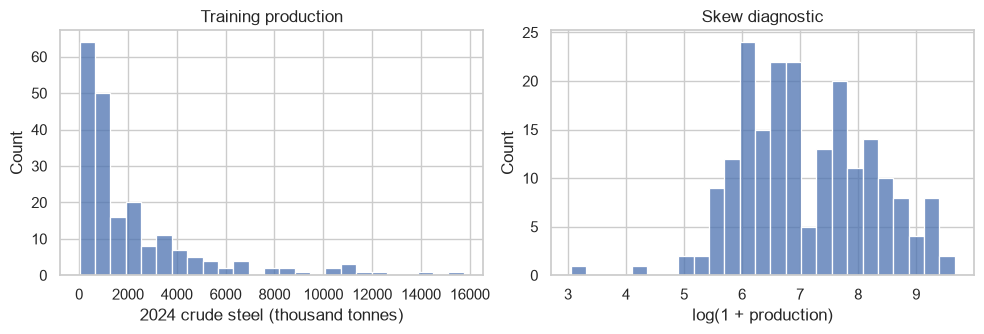

In [3]:
def numeric_source(values: pd.Series, structural_zero: bool = False) -> pd.Series:
    text = values.astype(str).str.strip()
    if structural_zero:
        text = text.replace({"N/A": "0"})
    return pd.to_numeric(text, errors="coerce").astype(float)


clean = pd.DataFrame(index=df.index)
clean[ID] = df[ID]
clean["production_2024_ttpa"] = numeric_source(df["production_2024_ttpa"])
capacity_names = dict(
    zip(
        CAPACITY_COLUMNS,
        ["steel_capacity_ttpa", "iron_capacity_ttpa", "eaf_capacity_ttpa"],
    )
)
status_membership = capacities.pivot(
    index=ID, columns="Status", values="Plant name (English)"
).notna()
active_flags = (
    status_membership.reindex(df[ID])[ACTIVE_STATUSES]
    .fillna(False)
    .reset_index(drop=True)
)
for original, normalized in capacity_names.items():
    parts = []
    for status in ACTIVE_STATUSES:
        part = numeric_source(df[f"{original} [{status}]"], structural_zero=True)
        # Absent status is zero; an existing status with unknown quantity stays NaN.
        part = part.where(active_flags[status], 0.0)
        parts.append(part)
    clean[normalized] = pd.concat(parts, axis=1).sum(axis=1, skipna=False)
clean["workforce"] = numeric_source(df["Workforce size"])
clean["plant_age"] = numeric_source(df["Plant age"])
for source, destination in [
    ("Country/area", "country"),
    ("Main production equipment", "equipment"),
]:
    clean[destination] = (
        df[source].replace({"": "unknown", "N/A": "not applicable"}).astype(str)
    )
# Equipment is a set of routes; source order does not define a new technology.
clean["equipment"] = clean["equipment"].map(
    lambda value: "; ".join(
        sorted({part.strip() for part in value.split(";") if part.strip()})
    )
)
clean["active_status"] = np.select(
    [
        active_flags.all(axis=1),
        active_flags["operating"],
        active_flags["operating pre-retirement"],
    ],
    ["both", "operating", "operating pre-retirement"],
    default="no active capacity",
)
print("Negative numeric entries:")
display(clean[BASE_NUMERIC + ["production_2024_ttpa"]].lt(0).sum().to_frame("count"))
assert not clean[BASE_NUMERIC + ["production_2024_ttpa"]].lt(0).any().any()
# Zero workers cannot be a denominator and does not mean a missing target is zero.
clean.loc[clean["workforce"].eq(0), "workforce"] = np.nan
labelled = clean[clean["production_2024_ttpa"].notna()].copy().set_index(ID)
print("Plants retained:", len(labelled), "of", len(df))
print("Rows excluded for missing target:", len(df) - len(labelled))
print(
    "Observed output but no active 2026 capacity:",
    int(labelled["active_status"].eq("no active capacity").sum()),
)
normalized_schema = input_schema()
normalized_schema.validate(labelled[FEATURES], lazy=True)
pa.SeriesSchema(float, pa.Check.ge(0), nullable=False).validate(
    labelled["production_2024_ttpa"]
)
normalized_schema.to_yaml(ARTIFACTS / "input_schema.yaml")

# Freeze the holdout before plots, feature inspection, imputation or model fitting.
X_train, X_test, y_train, y_test = train_test_split(
    labelled[FEATURES],
    labelled["production_2024_ttpa"],
    test_size=0.20,
    random_state=SEED,
)
assert set(X_train.index).isdisjoint(X_test.index)
print("Training/test plants:", len(X_train), len(X_test))
split_manifest = pd.DataFrame(
    {
        ID: labelled.index,
        "split": np.where(labelled.index.isin(X_train.index), "train", "test"),
    }
)
split_manifest.to_csv(ARTIFACTS / "split_manifest.csv", index=False)
labelled.to_csv(ARTIFACTS / "clean_plant_data.csv")
display(X_train[BASE_NUMERIC].describe().T)
q1, q3 = X_train[BASE_NUMERIC].quantile(0.25), X_train[BASE_NUMERIC].quantile(0.75)
outlier_counts = (
    (X_train[BASE_NUMERIC] < q1 - 1.5 * (q3 - q1))
    | (X_train[BASE_NUMERIC] > q3 + 1.5 * (q3 - q1))
).sum()
display(outlier_counts.to_frame("training_IQR_flags_not_deleted"))
print("Training target skew:", round(float(y_train.skew()), 3))
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
sns.histplot(y_train, ax=axes[0], bins=25)
axes[0].set(title="Training production", xlabel="2024 crude steel (thousand tonnes)")
sns.histplot(np.log1p(y_train), ax=axes[1], bins=25)
axes[1].set(title="Skew diagnostic", xlabel="log(1 + production)")
fig.tight_layout()
fig.savefig(ARTIFACTS / "target_distribution.png", dpi=160)
plt.show()

> 📝 *Critical thinking:*
> Explain your cleaning choices. Why did you treat the missing or skewed data in that way?


**Answer**

Unknown labels are removed, never imputed, because fabricated outcomes would contaminate both training and evaluation. The source's `N/A` capacity denotes an absent route, so it becomes zero. `unknown` and `>0` are not precise quantities and remain missing. If either present active-status component is unknown, its aggregate remains missing instead of becoming a misleading partial sum.

Median numeric imputation and missingness indicators are fitted inside the pipeline, separately in each CV fold. Large plants remain in the sample: an IQR flag is not evidence of an incorrect observation. The log plot diagnoses skew; `log(1 + capacity)` is a predictor, while the target stays in physical units so RMSE reflects large absolute production errors. Seven positive-output plants have no active capacity in the later snapshot. They are retained and identified as evidence of timing mismatch.

Equipment route strings are sorted and deduplicated, so the same combination in a different source order maps to the same category.

### **Task 1.4 - Feature Engineering**
- Create at least two new variables that might improve model performance (e.g., “capacity per worker”, “energy efficiency”).
- Encode categorical variables and standardize numeric ones.
- Bonus: you are free to use external socioeconomic or environmental data sources to enhance your feature set.


In [4]:
NUMERIC_FEATURES = BASE_NUMERIC + ENGINEERED
numeric_pipeline = Pipeline(
    [
        (
            "impute",
            SimpleImputer(
                strategy="median", add_indicator=True, keep_empty_features=True
            ),
        ),
        ("scale", StandardScaler()),
    ]
)
categorical_pipeline = Pipeline(
    [
        ("impute", SimpleImputer(strategy="most_frequent")),
        (
            "encode",
            OneHotEncoder(handle_unknown="ignore", drop="first", sparse_output=False),
        ),
    ]
)
preprocessor = ColumnTransformer(
    [
        ("numeric", numeric_pipeline, NUMERIC_FEATURES),
        ("category", categorical_pipeline, CATEGORICAL),
    ]
)


def make_pipeline(estimator: BaseEstimator) -> Pipeline:
    return Pipeline(
        [
            ("features", FunctionTransformer(engineer_features, validate=False)),
            ("preprocess", clone(preprocessor)),
            ("model", estimator),
        ]
    )


preview = engineer_features(X_train)
display(preview[BASE_NUMERIC + ENGINEERED].head())
print(
    "Preprocessing defined, not fitted. Every fit below happens on training rows only."
)
print("Numeric fields:", NUMERIC_FEATURES)
print("Categorical fields:", CATEGORICAL)

,steel_capacity_ttpa,iron_capacity_ttpa,eaf_capacity_ttpa,workforce,plant_age,log_steel_capacity,capacity_per_worker,eaf_share
GEM plant ID,,,,,,,,
P100001042874,200.0,0.0,200.0,869.0,64.00,5.303305,0.230150,1.000000
P100000120945,3100.0,0.0,3100.0,696.0,29.00,8.039480,4.454023,1.000000
P100000121028,3360.0,3860.0,0.0,4500.0,72.38,8.119994,0.746667,0.000000
P100000120519,11899.0,13570.0,1500.0,929.0,32.00,9.384294,12.808396,0.126061
P100000120924,800.0,0.0,800.0,754.0,216.00,6.685861,1.061008,1.000000


Preprocessing defined, not fitted. Every fit below happens on training rows only.
Numeric fields: ['steel_capacity_ttpa', 'iron_capacity_ttpa', 'eaf_capacity_ttpa', 'workforce', 'plant_age', 'log_steel_capacity', 'capacity_per_worker', 'eaf_share']
Categorical fields: ['country', 'equipment', 'active_status']


> 📝 *Critical thinking:*
> Document your new feature(s). What business or operational insight do they represent?


**Answer**

`capacity_per_worker` measures installed steel capacity per reported worker, in thousand tonnes per worker per year. It is a capital-intensity proxy, not observed labour productivity. `eaf_share` measures EAF's share of active steel capacity and represents production-route mix. Zero denominators produce missing values, handled by the pipeline. `log_steel_capacity` allows a nonlinear scale relationship without fitting a transform to test data.

No feature uses realized production or utilization computed from the target. One-hot encoding represents country, equipment and active-status categories. Numeric scaling gives each imputed numeric feature unit training standard deviation. All fitted transformations live inside the model pipeline, including row-wise feature creation for later inference.

## 🔍 1.5 Feature Relationships and Correlations

### 🧭 Objective
Before training models, it’s essential to understand how features relate to each other and to the target variable : both linearly and nonlinearly. This helps identify redundant or uninformative predictors and guides model choice.

---

### **Task 1.5.1 - Correlation Matrix (Linear Relationships)**
- Compute a **correlation matrix** (e.g., using `df.corr()`, `seaborn.heatmap`, `skrub`) to examine pairwise linear relationships among numerical features.
- Focus on correlations between each feature and the target (`production`), as well as between features themselves.


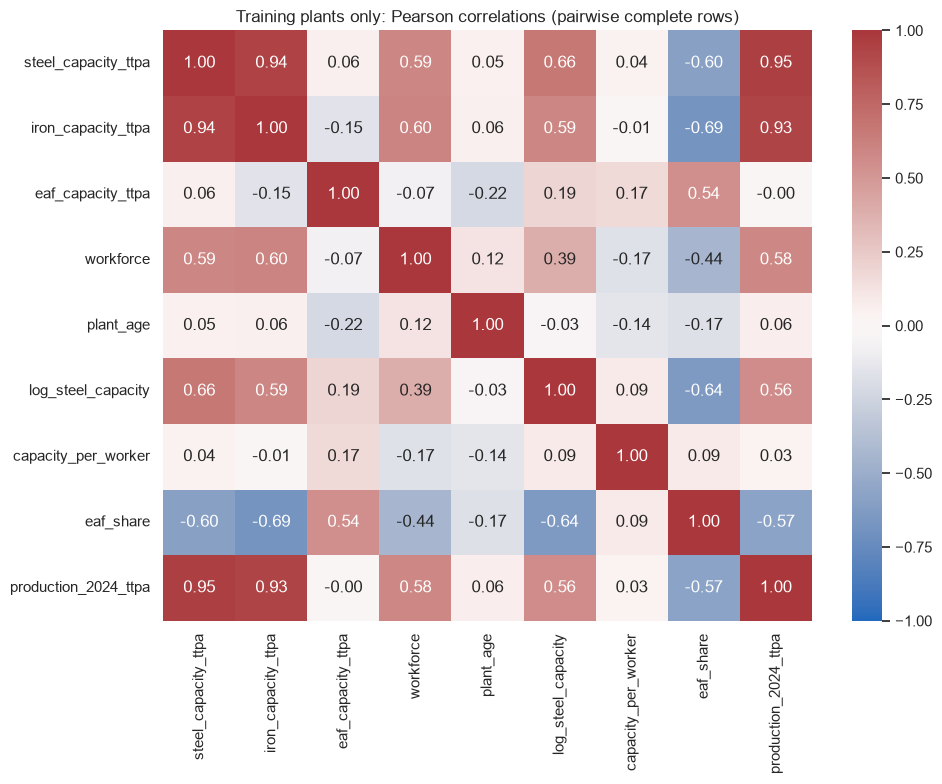

,Pearson_r
steel_capacity_ttpa,0.953477
iron_capacity_ttpa,0.931556
workforce,0.584742
eaf_share,-0.573967
log_steel_capacity,0.555962
plant_age,0.063760
capacity_per_worker,0.034834
eaf_capacity_ttpa,-0.003476


,feature_1,feature_2,r
0,steel_capacity_ttpa,iron_capacity_ttpa,0.938309


Strongest target relationship: steel_capacity_ttpa 0.953


In [5]:
correlation_data = engineer_features(X_train)[NUMERIC_FEATURES].join(y_train)
corr = correlation_data.corr(numeric_only=True)
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="vlag", center=0, vmin=-1, vmax=1, ax=ax)
ax.set_title("Training plants only: Pearson correlations (pairwise complete rows)")
fig.tight_layout()
fig.savefig(ARTIFACTS / "correlations.png", dpi=160)
plt.show()
target_correlations = (
    corr["production_2024_ttpa"]
    .drop("production_2024_ttpa")
    .sort_values(key=abs, ascending=False)
)
display(target_correlations.to_frame("Pearson_r"))
feature_corr = corr.loc[NUMERIC_FEATURES, NUMERIC_FEATURES]
redundant = [
    (a, b, float(cast(float, feature_corr.loc[a, b])))
    for i, a in enumerate(NUMERIC_FEATURES)
    for b in NUMERIC_FEATURES[i + 1 :]
    if abs(cast(float, feature_corr.loc[a, b])) >= 0.80
]
display(pd.DataFrame(redundant, columns=["feature_1", "feature_2", "r"]))
print(
    "Strongest target relationship:",
    target_correlations.index[0],
    round(float(target_correlations.iloc[0]), 3),
)

> 📝 *Critical thinking:*
> Which variables show the strongest correlation with production?
> Do any features appear redundant or highly correlated with each other?


**Answer**

**Steel capacity is strongest (r = 0.953), followed by iron capacity (r = 0.932).** Workforce has r = 0.585 and EAF share has r = -0.574. Steel and iron capacity are highly correlated with each other (r = 0.938), which makes their separate effects difficult to identify. Capacity per worker has little linear association with the target (r = 0.035).

The ordered table identifies the strongest observed relationships with production; the second table lists feature pairs with absolute Pearson correlation at least 0.80. Capacity and its log transform both describe size, while steel capacity and iron capacity can overlap for integrated plants. This redundancy makes individual linear coefficients less stable and motivates Ridge regularization.

Correlations use only training plants and pairwise available observations, so different pairs may use different sample sizes. They describe association, not causation; they cannot capture all threshold effects or equipment interactions. No test observations are used to revise the feature set.

## 🧮 2. Building Baseline & Linear Models

### 🧭 Objective
Establish a simple baseline, then train and interpret a linear model.

---

### **Task 2.1 - Baseline**
- Compute a simple baseline predictor (mean or median production) with `sklearn.dummy.DummyRegressor`. Report RMSE and MAE on the held-out test set.
- Build a second baseline as a pipeline, using **one** of the following. Fit preprocessing on the training split only (inside the pipeline, not on the full table):
  - **scikit-learn:** a `Pipeline` with preprocessing (`ColumnTransformer`: impute, encode categoricals, scale numerics) and a default regressor.
  - **skrub:** [`tabular_pipeline("regressor")`](https://skrub-data.org/stable/reference/generated/skrub.tabular_pipeline.html), which wires a `TableVectorizer` to an estimator-appropriate preprocessor.
- Compare the pipeline’s RMSE and MAE with the dummy baseline.


In [6]:
def metrics(actual: pd.Series, predicted: NDArray[np.float64]) -> dict[str, float]:
    return {
        "RMSE": float(root_mean_squared_error(actual, predicted)),
        "MAE": float(mean_absolute_error(actual, predicted)),
        "R2": float(r2_score(actual, predicted)),
    }


dummy = DummyRegressor(strategy="mean").fit(X_train, y_train)
rf_default = make_pipeline(RandomForestRegressor(random_state=SEED, n_jobs=1))
rf_default.fit(X_train, y_train)
baseline_results = pd.DataFrame(
    {
        "Dummy mean": metrics(y_test, dummy.predict(X_test)),
        "Default RF pipeline": metrics(y_test, rf_default.predict(X_test)),
    }
).T
baseline_results.index.name = "model"
display(baseline_results.round(3))
baseline_results.to_csv(ARTIFACTS / "baseline_test_metrics.csv")
improvement = 100 * (
    1
    - cast(float, baseline_results.loc["Default RF pipeline", "RMSE"])
    / cast(float, baseline_results.loc["Dummy mean", "RMSE"])
)
print(f"Pipeline test RMSE improvement over dummy: {improvement:.1f}%")
for column in CATEGORICAL:
    unseen = sorted(set(X_test[column]) - set(X_train[column]))
    print(f"Unseen test {column} values: {unseen}")
print(
    "Unseen categories use all-zero one-hot encoding. This is a limitation, not a schema error."
)

,RMSE,MAE,R2
model,,,
Dummy mean,3905.014,2245.797,-0.004
Default RF pipeline,885.115,404.452,0.948


Pipeline test RMSE improvement over dummy: 77.3%
Unseen test country values: ['Bosnia and Herzegovina', 'Bulgaria', 'Norway', 'Romania', 'Serbia', 'Venezuela', 'Zimbabwe']
Unseen test equipment values: ['BF; BOF; DRI; EAF; IF; Steel other/unspecified', 'BF; DRI; EAF; IF; Steel other/unspecified', 'BF; EAF; IF', 'BF; EAF; Steel other/unspecified']
Unseen test active_status values: []
Unseen categories use all-zero one-hot encoding. This is a limitation, not a schema error.


> 📝 *Critical thinking:*
> Why is it useful to have a baseline model before trying more complex ones?
> Did your pipeline beat the dummy baseline? If the gap is small, what does that say about the features?


**Answer**

**Yes.** The default Random Forest reduces test RMSE from **3,905.0 to 885.1 thousand tonnes**, a **77.3% reduction**. MAE falls from **2,245.8 to 404.5 thousand tonnes**. The gap is large, so the supplied plant attributes carry predictive information within this retrospective sample.

A mean predictor measures how much error remains when the model ignores plant attributes. The displayed RMSE comparison tests whether the features improve on that minimal reference. MAE describes a typical absolute error, while RMSE gives larger misses more weight. The printed percentage reports the actual gap; a small or negative gap would suggest weak features, poor measurement alignment, or insufficient labelled data, rather than automatically justifying a more complex model. These requested test scores are descriptive only; later selection uses CV on the training partition.

### **Task 2.2 - Linear Regression**
- Train a multiple linear regression model using the key plant variables.
- Display coefficients and interpret their meaning.
- Evaluate the model on training and test data.


In [7]:
linear = make_pipeline(LinearRegression()).fit(X_train, y_train)
linear_results = pd.DataFrame(
    {
        "train": metrics(y_train, linear.predict(X_train)),
        "test": metrics(y_test, linear.predict(X_test)),
    }
).T
display(linear_results.round(3))
feature_names = linear.named_steps["preprocess"].get_feature_names_out()
coefficients = pd.Series(
    linear.named_steps["model"].coef_, index=feature_names, name="coefficient_ttpa"
)
with pd.option_context("display.max_rows", None):
    display(coefficients.sort_values().to_frame())
coefficients.to_csv(ARTIFACTS / "linear_coefficients.csv")
encoder = (
    linear.named_steps["preprocess"]
    .named_transformers_["category"]
    .named_steps["encode"]
)
print(
    "Dropped category references:",
    dict(zip(CATEGORICAL, [str(v[0]) for v in encoder.categories_])),
)
numeric_coefficients = coefficients[coefficients.index.str.startswith("numeric__")]
positive = numeric_coefficients[numeric_coefficients > 0].sort_values(ascending=False)
negative = numeric_coefficients[numeric_coefficients < 0].sort_values()
if len(positive) and len(negative):
    display(
        Markdown(
            f"**Measured examples:** `{positive.index[0]}` has coefficient **{positive.iloc[0]:,.1f}**; "
            f"`{negative.index[0]}` has coefficient **{negative.iloc[0]:,.1f}** thousand tonnes. "
            "A one-training-standard-deviation increase changes the fitted prediction by that amount, "
            "holding the other transformed columns constant."
        )
    )

,RMSE,MAE,R2
train,566.070,355.513,0.959
test,773.928,509.836,0.961


,coefficient_ttpa
category__country_Kazakhstan,-3011.586652
category__country_Indonesia,-2350.380489
category__equipment_BOF; DRI; EAF,-1866.240971
category__country_Moldova,-1337.675095
category__country_Qatar,-1224.961285
category__active_status_operating pre-retirement,-1073.539825
category__country_Ukraine,-710.577254
category__country_Italy,-648.066828
category__country_Libya,-607.954552
category__equipment_BF; EAF,-577.818765


Dropped category references: {'country': 'Algeria', 'equipment': 'BF; BOF', 'active_status': 'both'}


**Measured examples:** `numeric__steel_capacity_ttpa` has coefficient **1,728.7**; `numeric__capacity_per_worker` has coefficient **-40.9** thousand tonnes. A one-training-standard-deviation increase changes the fitted prediction by that amount, holding the other transformed columns constant.

> 📝 *Critical thinking:*
> Interpret one positive and one negative coefficient. What do they tell you about plant performance drivers?


**Answer**

Steel capacity has a positive standardized coefficient of **+1,728.7 thousand tonnes**: larger installed capacity is associated with greater fitted output, conditional on the other transformed columns. Capacity per worker has a negative coefficient of **-40.9 thousand tonnes** per training standard deviation. This is a small conditional association after controlling for plant size and workforce, not evidence that capital intensity reduces production. Linear Regression has training/test RMSE of **566.1 / 773.9** and training/test R² of **0.959 / 0.961**; this split does not by itself show severe overfitting, though CV varies more.

The cell prints one positive and one negative numeric coefficient from the fitted model, with their actual magnitudes and units. The positive coefficient is a conditional upward association with fitted production; the negative coefficient is a conditional downward association. Numeric predictors and missingness indicators are standardized. One-hot coefficients are differences from each printed reference category.

Because capacity, log-capacity and capacity per worker are linked, holding every other transformed feature constant may not describe a physically possible plant change. Negative coefficients can reflect collinearity, reporting differences or equipment mix. They do not establish that increasing capacity or employment causes production to fall. Compare training and test errors to judge whether this fit generalizes.

## 🔁 3. Model Evaluation and Selection

### 🧭 Objective
Use cross-validation to estimate generalization performance and compare multiple model types.

---

### **Task 3.1 - Cross-Validation**
- Apply **K-Fold cross-validation** (e.g., K=5).
- Record the average RMSE, MAE, and R² across folds.


In [8]:
cv = KFold(n_splits=5, shuffle=True, random_state=SEED)
folds = list(cv.split(X_train, y_train))
scoring = {
    "RMSE": "neg_root_mean_squared_error",
    "MAE": "neg_mean_absolute_error",
    "R2": "r2",
}


def cv_results(model: Pipeline) -> pd.DataFrame:
    result = cross_validate(
        model,
        X_train,
        y_train,
        cv=folds,
        scoring=scoring,
        n_jobs=1,
        error_score="raise",
    )
    return pd.DataFrame(
        {
            "fold": np.arange(1, 6),
            "RMSE": -result["test_RMSE"],
            "MAE": -result["test_MAE"],
            "R2": result["test_R2"],
        }
    ).set_index("fold")


linear_cv = cv_results(make_pipeline(LinearRegression()))
display(linear_cv.round(3))
display(linear_cv.agg(["mean", "std"]).round(3))
print(
    "RMSE coefficient of variation:",
    round(float(linear_cv.RMSE.std() / linear_cv.RMSE.mean()), 3),
)

,RMSE,MAE,R2
fold,,,
1,854.653,585.334,0.790
2,985.042,648.464,0.925
3,1157.808,830.491,0.551
4,1022.151,619.478,0.910
5,1017.144,699.637,0.856


,RMSE,MAE,R2
mean,1007.360,676.681,0.806
std,108.128,95.652,0.152


RMSE coefficient of variation: 0.107


> 📝 *Critical thinking:*
> Summarize your results. How stable is performance across folds? What might this indicate about model variance?


**Answer**

Linear Regression averages **RMSE 1,007.4 ± 108.1**, **MAE 676.7 ± 95.7 thousand tonnes**, and **R² 0.806 ± 0.152** across five folds. Fold RMSE ranges from **854.7 to 1,157.8**, with a coefficient of variation of **10.7%**. Error magnitude is moderately variable, while R² ranges from **0.551 to 0.925**, showing that apparent explanatory power is sensitive to which plants are held out.

The table reports every fold and the mean plus sample standard deviation of each metric. A higher RMSE standard deviation relative to its mean signals sensitivity to which plants enter validation. Large plants and sparse country/equipment categories can make folds uneven in this small labelled sample. R² is computed separately within each fold, so its mean is not pooled R². Five folds are overlapping training experiments, not five independent datasets; their standard deviation is a stability diagnostic, not a confidence interval. Random plant splits estimate same-population performance, not generalization to new years or unseen corporate groups.

### **Task 3.2 - Model Comparison**
Train and compare at least **three models**, on the same folds and metrics as Task 3.1:
- Linear Regression
- Ridge Regression (regularized linear)
- Random Forest Regressor

Record cross-validation performance for each model.

**Bonus : tabular foundation model:** add [TabFM](https://github.com/google-research/tabfm) v1.0 (Google Research). Install the PyTorch extra from that repo, then:

```python
from tabfm import TabFMRegressor
from tabfm import tabfm_v1_0_0_pytorch as tabfm_v1_0_0

reg = TabFMRegressor(model=tabfm_v1_0_0.load(model_type="regression"))
```

`fit` stores the training rows as context; `predict` is one forward pass, with no hyperparameter search. The default context is 100 rows (`max_num_rows`). A single held-out split is enough. Pretrained weights are non-commercial and not for production. In the results table, say whether it beats your best classical model, and which model you would actually deploy. Python 3.11 or newer is required.


In [9]:
models = {
    "Linear Regression": make_pipeline(LinearRegression()),
    "Ridge": make_pipeline(Ridge()),
    "Random Forest": make_pipeline(RandomForestRegressor(random_state=SEED, n_jobs=1)),
}
cv_tables = {"Linear Regression": linear_cv}
for name in ["Ridge", "Random Forest"]:
    cv_tables[name] = cv_results(models[name])
comparison = pd.DataFrame(
    {
        name: {
            f"{metric}_{stat}": float(getattr(table[metric], stat)())
            for metric in ["RMSE", "MAE", "R2"]
            for stat in ["mean", "std"]
        }
        for name, table in cv_tables.items()
    }
).T.sort_values("RMSE_mean")
display(comparison.round(3))
comparison.to_csv(ARTIFACTS / "cv_model_comparison.csv")
pd.concat(cv_tables, names=["model", "fold"]).to_csv(ARTIFACTS / "cv_fold_metrics.csv")
top_name = str(comparison.index[0])
print("Lowest mean training-CV RMSE:", top_name)

# Bonus: recorded TabFM inference on this exact held-out split.
# RERUN_TABFM=1 requests fresh inference in the separate TabFM environment.
# With no rerun flag, verify and use the committed measured predictions.
bonus_path = ARTIFACTS / "tabfm_result.json"
if os.environ.get("RERUN_TABFM") == "1" or not bonus_path.exists():
    tabfm_python = Path(
        os.environ.get("TABFM_PYTHON", str(BASE / ".tabfm-venv/bin/python"))
    )
    if not tabfm_python.exists():
        raise FileNotFoundError(
            "Set up .tabfm-venv using requirements-tabfm.txt; see README."
        )
    command = [
        str(tabfm_python),
        str(BASE / "run_tabfm.py"),
        "--artifacts",
        str(ARTIFACTS),
        "--output",
        str(bonus_path),
    ]
    if os.environ.get("TABFM_CHECKPOINT"):
        command += ["--checkpoint", os.environ["TABFM_CHECKPOINT"]]
    subprocess.run(command, check=True, cwd=BASE)
tabfm_result = json.loads(bonus_path.read_text())
assert tabfm_result["status"] == "completed"
assert (
    tabfm_result["checkpoint_sha256"]
    == "bd5a615b0322a8f04a895038de6df6fbd71430eca750e1d792f31048654674a9"
)
assert tabfm_result["config_git_blob"] == "61e3f1b7e6042b89fcfb21ef8e866c32b5f43cde"
assert tabfm_result["config"]["n_estimators"] == 1
assert tabfm_result["source_revision"] == "fbb665569425fd2f490c6576b3af967876fe11ff"
assert tabfm_result["weights_revision"] == "77cb9cc1b4fd3a9c77fbb9552c218200bb4dab83"
assert (
    tabfm_result["dataset_sha256"]
    == hashlib.sha256((ARTIFACTS / "clean_plant_data.csv").read_bytes()).hexdigest()
)
assert (
    tabfm_result["split_sha256"]
    == hashlib.sha256((ARTIFACTS / "split_manifest.csv").read_bytes()).hexdigest()
)
assert tabfm_result["features"] == FEATURES + ENGINEERED
recorded_predictions = pd.DataFrame(tabfm_result["predictions"]).set_index(ID)
assert recorded_predictions.index.is_unique
assert set(recorded_predictions.index) == set(X_test.index)
np.testing.assert_allclose(recorded_predictions.loc[X_test.index, "actual"], y_test)
tabfm_predictions = recorded_predictions.loc[X_test.index, "prediction"].to_numpy(
    dtype=float
)
assert np.isfinite(tabfm_predictions).all()
tabfm_test_metrics = metrics(y_test, tabfm_predictions)
for metric_name, value in tabfm_test_metrics.items():
    np.testing.assert_allclose(
        value, tabfm_result["metrics"][metric_name.lower()], rtol=1e-10
    )
assert sum(len(patterns) for patterns in tabfm_result["context_ids"].values()) == 1
for context_patterns in tabfm_result["context_ids"].values():
    for context_ids in context_patterns:
        assert len(context_ids) == len(set(context_ids)) == 100
        assert set(context_ids).issubset(set(X_train.index))
        assert set(context_ids).isdisjoint(set(X_test.index))
bonus_comparison = pd.DataFrame(
    {
        "Default RF pipeline": baseline_results.loc["Default RF pipeline"].to_dict(),
        "Linear Regression": linear_results.loc["test"].to_dict(),
        "TabFM v1.0 (one estimator, 100-row context)": tabfm_test_metrics,
    }
).T
print("Measured TabFM inference timestamp:", tabfm_result["completed_utc"])
print("Recorded configuration:", tabfm_result["config"])
print("Input and split hashes verified. No test rows occur in the training context.")
display(bonus_comparison.round(3))
recorded_predictions.to_csv(ARTIFACTS / "tabfm_test_predictions.csv")
bonus_comparison.to_csv(ARTIFACTS / "tabfm_comparison.csv")

,RMSE_mean,RMSE_std,MAE_mean,MAE_std,R2_mean,R2_std
Random Forest,825.327,180.259,514.160,88.900,0.889,0.060
Ridge,883.870,119.098,588.480,55.691,0.865,0.082
Linear Regression,1007.360,108.128,676.681,95.652,0.806,0.152


Lowest mean training-CV RMSE: Random Forest
Measured TabFM inference timestamp: 2026-09-25T09:48:29.478088+00:00
Recorded configuration: {'max_num_rows': 100, 'n_estimators': 1, 'random_state': 42, 'batch_size': 1, 'device': 'cpu', 'dtype': 'bfloat16', 'threads': 4}
Input and split hashes verified. No test rows occur in the training context.


,RMSE,MAE,R2
Default RF pipeline,885.115,404.452,0.948
Linear Regression,773.928,509.836,0.961
"TabFM v1.0 (one estimator, 100-row context)",554.283,385.395,0.980


> 📝 *Critical thinking:*
> Create a small results table. Which model performs best? Why might that be the case given the dataset’s characteristics?


**Answer**

**Random Forest wins the default-model CV comparison:** mean RMSE **825.3**, versus **883.9 for Ridge** and **1,007.4 for Linear Regression**. Random Forest has mean MAE **514.2** and R² **0.889**. Its RMSE fold standard deviation is **180.3**, larger than Ridge’s **119.1**, so the mean advantage comes with greater fold variability. Nonlinear relationships and route interactions are plausible reasons for its lead; this comparison does not prove which mechanism caused it.

The results table names the winner by lowest mean five-fold RMSE, with MAE and R² shown on the same folds. Random Forest can capture thresholds and route interactions, but may struggle with plants larger than those in its training set. Linear Regression can extrapolate with capacity, but correlated features and rare categories make its coefficients unstable. Ridge shrinks coefficients and can reduce that instability. The measured CV ranking, rather than a preference for model complexity, determines which family is tuned next.

**Measured TabFM result:** RMSE **554.3 thousand tonnes**, MAE **385.4 thousand tonnes**, and R² **0.980** on all **52 held-out plants**. It beats the CV-selected tuned Random Forest (RMSE **976.9**) and Linear Regression, the strongest reported classical model on this test split (RMSE **773.9**). This is one fixed held-out evaluation, not proof of superiority across releases or future years. The pretrained model could also have prior exposure to related public data; this experiment cannot rule that out.

**TabFM bonus:** the code above verifies and evaluates predictions produced by the official TabFM v1.0 regression checkpoint. `run_tabfm.py` contains the actual model call:

```python
model = tabfm_v1_0_0_pytorch.load(model_type="regression", checkpoint_path=checkpoint, device="cpu", dtype=torch.bfloat16)
regressor = TabFMRegressor(model=model, n_estimators=1, max_num_rows=100, random_state=42, batch_size=1)
regressor.fit(x_train, y_train)
predictions = regressor.predict(x_test)
```

A single estimator was fixed before evaluation to keep this 6.6 GB checkpoint practical on the local machine. It is not the library's default 32-estimator ensemble. The 100 context plants are sampled from the same 205 training plants; all 52 held-out plants are evaluated. TabFM receives the same eight base columns and three deterministic features as the classical models, with its own native preprocessing. No TabFM hyperparameter search is performed. This compares the configured systems, not equal compute budgets.

The package wheel is version 1.0.1, built from a pinned official source commit; the pretrained checkpoint evaluated is v1.0.0. The separate environment avoids TabFM's `typeguard<3` requirement conflicting with Pandera. By default the notebook reuses measured predictions only after validating the input and split hashes, row identities, context membership and metrics. Set `RERUN_TABFM=1` to repeat actual inference. Results are not simulated or generated from the classical model.

The final comparison with the CV-selected tuned pipeline appears in Task 4.3. For deployment, retain the classical pipeline: the [official TabFM weights](https://github.com/google-research/tabfm#license-notice-for-pretrained-weights) permit only non-commercial, non-production use. The timing mismatch in this dataset still needs to be fixed before operational forecasting.


### **Task 3.3 - Hyperparameter Optimization**
- Use **RandomizedSearchCV** or **GridSearchCV** to tune the top model (e.g., Random Forest).
- Report the best parameters and corresponding validation score.


In [10]:
parameter_space: dict[str, Sequence[float | int | bool | None]]
if top_name == "Random Forest":
    parameter_space = {
        "model__n_estimators": [100, 200, 300],
        "model__max_depth": [None, 5, 10, 20],
        "model__min_samples_leaf": [1, 2, 4, 8],
        "model__max_features": [0.6, 0.8, 1.0],
    }
elif top_name == "Ridge":
    parameter_space = {"model__alpha": np.logspace(-3, 4, 40).tolist()}
else:
    parameter_space = {
        "model__fit_intercept": [True, False],
        "model__positive": [True, False],
    }
search = RandomizedSearchCV(
    models[top_name],
    parameter_space,
    n_iter=min(12, int(math.prod(len(v) for v in parameter_space.values()))),
    scoring="neg_root_mean_squared_error",
    cv=folds,
    random_state=SEED,
    n_jobs=1,
    refit=True,
    error_score="raise",
)
search.fit(X_train, y_train)
search_rmse = -float(search.best_score_)
print("Tuned family:", top_name)
print("Best parameters:", search.best_params_)
print(
    "Default CV RMSE:",
    round(float(cast(float, comparison.loc[top_name, "RMSE_mean"])), 3),
)
print("Search best CV RMSE:", round(search_rmse, 3))
print(
    "CV RMSE reduction:",
    round(float(cast(float, comparison.loc[top_name, "RMSE_mean"])) - search_rmse, 3),
)
pd.DataFrame(search.cv_results_).to_csv(
    ARTIFACTS / "random_search_results.csv", index=False
)

Tuned family: Random Forest
Best parameters: {'model__n_estimators': 300, 'model__min_samples_leaf': 2, 'model__max_features': 1.0, 'model__max_depth': 5}
Default CV RMSE: 825.327
Search best CV RMSE: 811.693
CV RMSE reduction: 13.634


> 📝 *Critical thinking:*
> Discuss the role of hyperparameter tuning. How did tuning change your model’s performance compared to default settings?


**Answer**

The best random-search setting uses **300 trees, maximum depth 5, minimum leaf size 2, and all features**. CV RMSE improves from **825.3 to 811.7 thousand tonnes**, a **13.6 thousand tonne (1.65%)** reduction. This is a modest gain. The later held-out evaluation does **not** repeat that improvement: the selected model’s RMSE is **976.9**, versus **885.1** for the default forest and **773.9** for Linear Regression. The selected model is retained because the test set is excluded from selection; the disagreement shows uncertainty in this small-sample ranking.

Hyperparameters control model flexibility before fitting, so their evaluation must remain inside the training partition. The printed reduction is positive if tuning improves the default and negative if the sampled settings are worse. The default model remains eligible for final selection. Reusing the same folds makes candidates comparable, but choosing the best of several settings makes its reported CV score optimistic. The fixed test set is excluded from tuning and selection; nested CV would be preferable for an unbiased estimate of the whole tuning procedure.

## ⚙️ 4. Model Lifecycle: Tracking, Saving, and Loading

### 🧭 Objective
Apply tools that support reproducible ML experiments.

---

### **Task 4.1 - Experiment Tracking with MLflow**
- Use MLflow to log parameters (model type, hyperparameters), metrics (RMSE, R²), and artifacts (a plot, the feature list, or your Pandera schema).
- Run and record at least two experiments (for example the Task 2.1 baseline and your best model).


In [11]:
import mlflow
import optuna
from optuna.integration import MLflowCallback

TRACKING_URI = "sqlite:///" + str(BASE / "mlflow.db")
mlflow.set_tracking_uri(TRACKING_URI)
experiment_name = "lab2-steel-production"
existing_experiment = mlflow.get_experiment_by_name(experiment_name)
artifact_location = str(BASE / "mlflow_artifacts")
if (
    existing_experiment is not None
    and existing_experiment.artifact_location != artifact_location
):
    # Moving the folder must not send new artifacts to an old absolute path.
    experiment_name += "-" + hashlib.sha256(str(BASE).encode()).hexdigest()[:10]
if mlflow.get_experiment_by_name(experiment_name) is None:
    mlflow.create_experiment(experiment_name, artifact_location=artifact_location)
experiment = mlflow.set_experiment(experiment_name)
EXPERIMENT_ID = experiment.experiment_id
EXECUTION_ID = datetime.now(timezone.utc).strftime("%Y%m%dT%H%M%S%fZ")
(ARTIFACTS / "features.json").write_text(
    json.dumps({"raw_inputs": FEATURES, "engineered": ENGINEERED}, indent=2)
)


def log_experiment(
    name: str, estimator: BaseEstimator, reported_metrics: dict[str, float]
) -> str:
    with mlflow.start_run(run_name=name) as run:
        mlflow.set_tags(
            {
                "execution_id": EXECUTION_ID,
                "data_sha256": DATA_SHA256,
                "target_year": str(TARGET_YEAR),
                "predictor_snapshot": "June 2026",
            }
        )
        mlflow.log_params(
            {
                "model_type": type(estimator).__name__,
                "seed": SEED,
                "train_n": len(X_train),
                "test_n": len(X_test),
            }
        )
        model_params = estimator.get_params(deep=False)
        mlflow.log_params({key: str(value) for key, value in model_params.items()})
        mlflow.log_metrics(reported_metrics)
        for artifact_name in [
            "correlations.png",
            "features.json",
            "input_schema.yaml",
            "split_manifest.csv",
        ]:
            mlflow.log_artifact(str(ARTIFACTS / artifact_name))
        return str(run.info.run_id)


run_ids = {
    "dummy": log_experiment(
        "dummy-baseline",
        dummy,
        {
            f"test_{str(key).lower()}": value
            for key, value in baseline_results.loc["Dummy mean"].to_dict().items()
        },
    ),
    "search": log_experiment(
        "search-best",
        search.best_estimator_.named_steps["model"],
        {"cv_rmse": search_rmse},
    ),
}
display(pd.Series(run_ids, name="MLflow run ID").to_frame())
print("Tracking store:", TRACKING_URI)
with mlflow.start_run(run_name="tabfm-heldout-bonus") as tabfm_run:
    mlflow.set_tags(
        {
            "execution_id": EXECUTION_ID,
            "data_sha256": DATA_SHA256,
            "source_revision": tabfm_result["source_revision"],
            "weights_revision": tabfm_result["weights_revision"],
        }
    )
    mlflow.log_params({"model_type": "TabFM v1.0 regression", **tabfm_result["config"]})
    mlflow.log_metrics(
        {f"test_{key.lower()}": value for key, value in tabfm_test_metrics.items()}
    )
    mlflow.log_artifact(str(bonus_path))
    mlflow.log_artifact(str(ARTIFACTS / "tabfm_comparison.csv"))
    mlflow.log_artifact(str(BASE / "run_tabfm.py"))
    run_ids["tabfm"] = str(tabfm_run.info.run_id)
print("TabFM MLflow run:", run_ids["tabfm"])

/Users/adamzer/Documents/Codex/2026-09-25/ca/work/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026/09/25 11:49:46 INFO mlflow.agent.hint: Load the `instrumenting-with-mlflow-tracing` skill at /Users/adamzer/Documents/Codex/2026-09-25/ca/work/.venv/lib/python3.12/site-packages/mlflow/assistant/skills/instrumenting-with-mlflow-tracing/SKILL.md before writing any tracing code; it ships with this MLflow install. Set MLFLOW_DISABLE_AGENT_HINT=1 to silence this.


,MLflow run ID
dummy,18b186c6ebaa4b4bb6fc4090fe469ae4
search,249993c9050e40cb879e55a747d72214


Tracking store: sqlite:////Users/adamzer/Documents/Codex/2026-09-25/ca/outputs/lab_2_complete/mlflow.db
TabFM MLflow run: 77dc111800de45b5b66ea90a6a7bcd74


> 📝 *Critical thinking:*
> Describe how MLflow helps manage your experiments. What advantages does it give compared to manual tracking?


**Answer**

MLflow stores each run's parameters, metrics, input-data fingerprint and supporting artifacts under a run ID. The two runs above share the same local SQLite tracking store. This lets another reader trace a score back to its model settings, split and source release. A manual spreadsheet can record a score but is easier to detach from the exact feature definition, schema or plot. Tracking is only as reliable as what is logged; dataset checksums and explicit target/snapshot dates are therefore included.

### **Task 4.2 - Hyperparameter Optimization with Optuna**
- Define an Optuna study to optimize one classical model (Ridge or Random Forest). Skip TabFM here.
- Use a fixed budget (about 30 trials) and the same cross-validation metric as Task 3.
- Record the number of trials, the best parameters, and the score next to the untuned score from Task 3.2.
- Send the trials to the same store as Task 4.1 with `optuna.integration.MLflowCallback`.


In [12]:
optuna.logging.set_verbosity(optuna.logging.WARNING)
OPTUNA_FAMILY = top_name if top_name in ["Ridge", "Random Forest"] else "Ridge"


def objective(trial: optuna.Trial) -> float:
    if OPTUNA_FAMILY == "Ridge":
        estimator = Ridge(alpha=trial.suggest_float("alpha", 1e-3, 1e4, log=True))
    else:
        estimator = RandomForestRegressor(
            n_estimators=trial.suggest_categorical("n_estimators", [100, 200, 300]),
            max_depth=trial.suggest_categorical("max_depth", [None, 5, 10, 20]),
            min_samples_leaf=trial.suggest_int("min_samples_leaf", 1, 8),
            max_features=trial.suggest_float("max_features", 0.5, 1.0),
            random_state=SEED,
            n_jobs=1,
        )
    return float(cv_results(make_pipeline(estimator))["RMSE"].mean())


study = optuna.create_study(
    direction="minimize",
    sampler=optuna.samplers.TPESampler(seed=SEED),
    study_name="lab2-" + EXECUTION_ID,
    storage="sqlite:///" + str(BASE / "optuna.db"),
)
study.set_user_attr("model_family", OPTUNA_FAMILY)
study.set_user_attr("data_sha256", DATA_SHA256)
callback = MLflowCallback(
    tracking_uri=TRACKING_URI,
    metric_name="cv_rmse",
    create_experiment=False,
    mlflow_kwargs={
        "experiment_id": EXPERIMENT_ID,
        "tags": {"execution_id": EXECUTION_ID, "model_family": OPTUNA_FAMILY},
    },
)
study.optimize(objective, n_trials=30, callbacks=[callback], show_progress_bar=False)
assert len(study.trials) == 30
assert all(trial.state == optuna.trial.TrialState.COMPLETE for trial in study.trials)
print("Completed trials:", len(study.trials))
print("Optuna family:", OPTUNA_FAMILY)
print("Best parameters:", study.best_params)
optuna_comparison = pd.DataFrame(
    {
        "default": [float(cast(float, comparison.loc[OPTUNA_FAMILY, "RMSE_mean"]))],
        "Optuna best": [study.best_value],
    },
    index=["mean CV RMSE"],
)
display(optuna_comparison.round(3))
study.trials_dataframe().to_csv(ARTIFACTS / "optuna_trials.csv", index=False)
if OPTUNA_FAMILY == "Ridge":
    optuna_model = make_pipeline(Ridge(**study.best_params))
else:
    optuna_model = make_pipeline(
        RandomForestRegressor(**study.best_params, random_state=SEED, n_jobs=1)
    )

# Defaults stay eligible: tuning is not guaranteed to improve the model.
candidates = {
    name: (model, float(cast(float, comparison.loc[name, "RMSE_mean"])))
    for name, model in models.items()
}
candidates["RandomizedSearch: " + top_name] = (search.best_estimator_, search_rmse)
candidates["Optuna: " + OPTUNA_FAMILY] = (optuna_model, float(study.best_value))
best_name = min(candidates, key=lambda name: candidates[name][1])
best_pipeline = clone(candidates[best_name][0]).fit(X_train, y_train)
print("Final selection by training CV only:", best_name)

/var/folders/nm/1kdjw0m14kb2157pvpm5nc640000gn/T/ipykernel_73855/977271020.py:28: FutureWarning: MLflowCallback has been deprecated in v4.9.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v4.9.0.
  callback = MLflowCallback(


Completed trials: 30
Optuna family: Random Forest
Best parameters: {'n_estimators': 200, 'max_depth': None, 'min_samples_leaf': 2, 'max_features': 0.965085063641008}


,default,Optuna best
mean CV RMSE,825.327,813.165


Final selection by training CV only: RandomizedSearch: Random Forest


> 📝 *Critical thinking:*
> Explain what Optuna is doing behind the scenes. How is it different from Grid or Random Search?


**Answer**

All **30 trials completed**. Optuna’s best forest uses **200 trees, no maximum depth, minimum leaf size 2, and max_features = 0.965085**. Its CV RMSE is **813.2**, compared with **825.3** untuned. The randomized-search winner is slightly better at **811.7**, so it becomes the saved pipeline.

Optuna's TPE sampler begins with seed-controlled exploration, then uses previous trial scores to favour promising parts of the parameter space. Every trial fits a new complete pipeline on the same five training folds and returns mean RMSE. The fixed 30-trial budget makes runtime and the extent of search explicit; all trial results are exported and logged to the same MLflow store through `optuna.integration.MLflowCallback`.

Grid search evaluates a fixed Cartesian product. Random search samples without adapting to earlier scores. TPE adapts, but it does not guarantee a better result, and repeated reuse of validation folds can overfit selection. No trial reads test labels. If the best default family is unregularized Linear Regression, Optuna tunes Ridge, as required by this task, while all defaults and search winners remain eligible.

### **Task 4.3 - Model Storage**
- Save the best **pipeline** (preprocessing and model together), with `joblib` or `mlflow.sklearn.log_model`. Saving the estimator alone drops the encoder and imputer.
- Load the saved pipeline and re-evaluate it on the test set. The score should match the in-memory pipeline.


,RMSE,MAE,R2
in_memory,976.871,451.298,0.937
reloaded,976.871,451.298,0.937


Reload verification passed. Selected model: RandomizedSearch: Random Forest
Negative predictions: 0


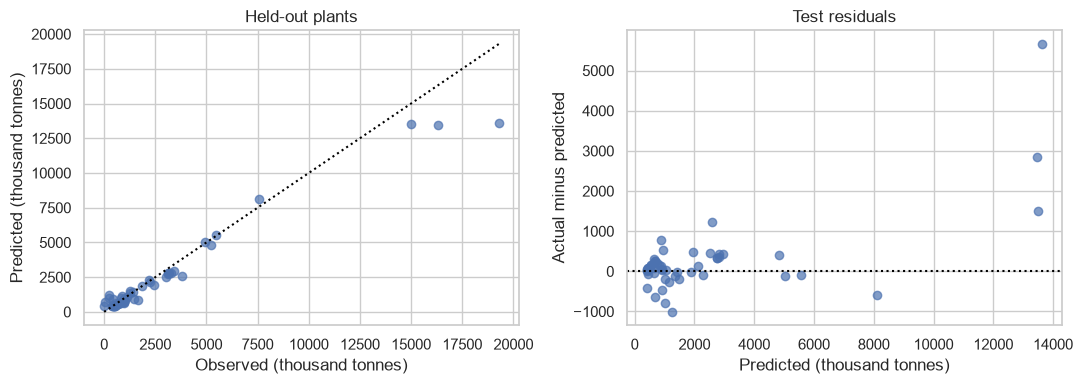

Verified MLflow run count: 34


,RMSE,MAE,R2
Default RF pipeline,885.115,404.452,0.948
Linear Regression,773.928,509.836,0.961
"TabFM v1.0 (one estimator, 100-row context)",554.283,385.395,0.980
CV-selected tuned Random Forest,976.871,451.298,0.937


TabFM beats selected classical RMSE: True
TabFM beats Linear Regression test RMSE: True


In [13]:
model_path = ARTIFACTS / "best_pipeline.joblib"
joblib.dump(best_pipeline, model_path)
loaded_pipeline = joblib.load(model_path)
in_memory_predictions = best_pipeline.predict(X_test)
loaded_predictions = loaded_pipeline.predict(X_test)
np.testing.assert_allclose(
    in_memory_predictions, loaded_predictions, rtol=0, atol=1e-10
)
final_metrics = metrics(y_test, loaded_predictions)
assert metrics(y_test, in_memory_predictions) == final_metrics
final_table = pd.DataFrame(
    {"in_memory": metrics(y_test, in_memory_predictions), "reloaded": final_metrics}
).T
display(final_table.round(3))
print("Reload verification passed. Selected model:", best_name)
print("Negative predictions:", int((loaded_predictions < 0).sum()))

predictions = pd.DataFrame(
    {"actual_ttpa": y_test, "predicted_ttpa": loaded_predictions}
)
predictions["residual_ttpa"] = (
    predictions["actual_ttpa"] - predictions["predicted_ttpa"]
)
predictions.to_csv(ARTIFACTS / "test_predictions.csv")
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].scatter(y_test, loaded_predictions, alpha=0.7)
limit = max(float(y_test.max()), float(loaded_predictions.max()))
axes[0].plot([0, limit], [0, limit], color="black", linestyle=":")
axes[0].set(
    xlabel="Observed (thousand tonnes)",
    ylabel="Predicted (thousand tonnes)",
    title="Held-out plants",
)
axes[1].scatter(loaded_predictions, y_test - loaded_predictions, alpha=0.7)
axes[1].axhline(0, color="black", linestyle=":")
axes[1].set(
    xlabel="Predicted (thousand tonnes)",
    ylabel="Actual minus predicted",
    title="Test residuals",
)
fig.tight_layout()
fig.savefig(ARTIFACTS / "final_diagnostics.png", dpi=160)
plt.show()
versions = {
    name: importlib.metadata.version(name)
    for name in [
        "pandas",
        "numpy",
        "scikit-learn",
        "pandera",
        "mlflow",
        "optuna",
        "optuna-integration",
        "joblib",
    ]
}
metadata = {
    "selected_model": best_name,
    "selected_cv_rmse": candidates[best_name][1],
    "test_metrics": final_metrics,
    "target": "2024 crude steel production",
    "units": "thousand metric tonnes",
    "snapshot": "June 2026 V1",
    "data_sha256": DATA_SHA256,
    "model_sha256": hashlib.sha256(model_path.read_bytes()).hexdigest(),
    "features": FEATURES,
    "engineered_features": ENGINEERED,
    "seed": SEED,
    "train_count": len(X_train),
    "test_count": len(X_test),
    "python": platform.python_version(),
    "versions": versions,
    "execution_id": EXECUTION_ID,
    "optuna_study": study.study_name,
    "limitation": "Retrospective snapshot model, not validated for future-year forecasting.",
}
(ARTIFACTS / "model_metadata.json").write_text(json.dumps(metadata, indent=2))
run_ids["final"] = log_experiment(
    "final-selected-pipeline",
    best_pipeline.named_steps["model"],
    {
        **{f"test_{key.lower()}": value for key, value in final_metrics.items()},
        "cv_rmse": candidates[best_name][1],
    },
)
with mlflow.start_run(run_id=run_ids["final"]):
    for artifact in [
        "best_pipeline.joblib",
        "model_metadata.json",
        "final_diagnostics.png",
    ]:
        mlflow.log_artifact(str(ARTIFACTS / artifact))
    mlflow.log_artifact(str(BASE / "lab_utils.py"))
(ARTIFACTS / "run_ids.json").write_text(json.dumps(run_ids, indent=2))
runs = mlflow.search_runs(
    experiment_ids=[EXPERIMENT_ID],
    filter_string=f"tags.execution_id = '{EXECUTION_ID}'",
)
assert (
    len(runs) == 34
), f"Expected baseline + search + TabFM + 30 trials + final, got {len(runs)}"
runs.to_csv(ARTIFACTS / "mlflow_runs.csv", index=False)
print("Verified MLflow run count:", len(runs))
final_bonus_comparison = bonus_comparison.copy()
final_bonus_comparison.loc["CV-selected tuned Random Forest"] = pd.Series(final_metrics)
display(final_bonus_comparison.round(3))
final_bonus_comparison.to_csv(ARTIFACTS / "tabfm_comparison.csv")
print(
    "TabFM beats selected classical RMSE:",
    tabfm_test_metrics["RMSE"] < final_metrics["RMSE"],
)
print(
    "TabFM beats Linear Regression test RMSE:",
    tabfm_test_metrics["RMSE"] < float(cast(float, linear_results.loc["test", "RMSE"])),
)

> 📝 *Critical thinking:*
> Why is it important to store both model parameters and metadata? How would you ensure version control of models in a production setting?


**Answer**

The selected pipeline reloads with **RMSE 976.9**, **MAE 451.3 thousand tonnes**, and **R² 0.937** on **52 test plants**. Prediction equality passes at absolute tolerance **1e-10** and the metric dictionaries match exactly. It produces no negative test predictions. The diagnostic plot shows its largest underpredictions at the high-production end, consistent with the limited extrapolation of tree models.

The saved object includes feature engineering, imputation, scaling, category encoding and the regressor. Reloaded predictions and all test scores are checked against the in-memory pipeline. `lab_utils.py` is also required because it defines the serializable feature function.

Metadata records the data checksum, target year, snapshot date, feature names, package versions, split size, random seed, model checksum and measured scores. In production, version these together under one immutable model release, retain the training-data snapshot, and promote a release only after schema and prediction tests pass. A registry alias can identify the approved release while older artifacts remain available for rollback. Load only trusted joblib files, since deserialization executes Python objects.

The final bonus table reports TabFM alongside the classical models. TabFM has the lowest measured test RMSE (**554.3**) and MAE (**385.4**), but the stored deployment candidate remains the CV-selected classical pipeline because the pretrained TabFM weights prohibit production use. No test score was used to retune either system.

## 🚀 5. Deployment & Monitoring (Conceptual)

### 🧭 Objective
Reflect on how models transition from training to production and stay reliable over time.

---

### **Task 5.1 - Deployment Planning**

> 📝 *Critical thinking:*
> Describe how you would deploy the **saved pipeline** from Task 4.3 (REST API or batch job). Incoming rows should pass your Pandera schema before `predict`, so serving applies the same columns and checks as training.
> Which metrics would you monitor: error once actual production arrives, and the share of rows rejected by the schema?
> If you tried TabFM, would you deploy it or the classical pipeline? The pretrained weights are non-commercial and not for production use.


**Answer**

Deploy the saved pipeline as a scheduled batch job for normalized plant snapshots. An ingestion step must implement the documented source-sentinel and active-status rules before calling `predict_batch`; raw Excel strings are not the serving contract. The function validates the exact base input columns with the same Pandera schema used in training, then calls the pipeline, which creates features and applies its fitted transforms. The example below verifies both valid prediction and rejection of negative capacity.

Before operational use, replace the retrospective setup with predictors dated before the outcome year and evaluate on later years. Monitor RMSE, MAE and systematic over/underprediction once annual actuals arrive, both overall and by country/capacity band. Monitor schema rejection rate, missingness, unseen country/equipment values, prediction distribution and negative predictions before labels arrive. Log the model version and input snapshot for every batch. Reject malformed rows with reasons, alert on a rising rejected share, and review drift before retraining. Any decision to clip negative predictions requires a separately evaluated policy; the lab reports raw model predictions.

TabFM is evaluated for the lab only. Its pretrained weights prohibit production use, so the saved classical pipeline remains the deployment candidate regardless of the bonus score. Its smaller artifact and lower inference cost also simplify deployment.

In [14]:
# A runnable batch-inference example using the same normalized input schema.
example_input = X_test.head(5).copy()
example_input.to_csv(ARTIFACTS / "example_inputs.csv")
served_predictions = predict_batch(example_input, ARTIFACTS)
np.testing.assert_allclose(
    served_predictions, loaded_pipeline.predict(example_input), rtol=0, atol=1e-10
)
display(
    pd.DataFrame(
        {"predicted_production_ttpa": served_predictions}, index=example_input.index
    )
)
# Verify that malformed incoming data is rejected before prediction.
bad_input = example_input.copy()
bad_input.iloc[0, bad_input.columns.get_loc("steel_capacity_ttpa")] = -1.0
try:
    predict_batch(bad_input, ARTIFACTS)
except pa.errors.SchemaErrors:
    print("PASS: negative capacity rejected before prediction.")
else:
    raise AssertionError("Invalid capacity unexpectedly accepted.")

,predicted_production_ttpa
GEM plant ID,
P100000120661,5566.288245
P100000120951,534.372988
P100000120626,821.104806
P100000120513,8122.594597
P100000120803,760.952070


PASS: negative capacity rejected before prediction.


### **Task 5.2 - Detecting Model Drift**

> 📝 *Critical thinking:*
> What signs might indicate your model needs retraining?
> Give one example of **data drift** and one of **concept drift** relevant to steel plant production.
> Name one column from your Pandera schema you would watch first, and what shift in that column would count as data drift.


**Answer**

Retraining becomes a candidate when error rises on newly observed production, residuals show persistent bias, or the incoming population moves beyond the training sample. First investigate measurement changes and broken ingestion; retraining cannot fix a changed unit definition.

**Data drift:** a new batch contains a larger share of high-capacity plants or more EAF facilities, changing the input distribution. Watch `steel_capacity_ttpa` first. As an initial policy, investigate a median capacity shift above 25% or a missingness increase above 10 percentage points for two batches of at least 30 plants. These thresholds are proposals to calibrate with historical batches, not statistical guarantees.

**Concept drift:** sustained electricity-price changes or demand restrictions reduce output for the same installed capacity and equipment. Then the relationship between capacity and actual production has changed even if the input distribution remains similar. Detect this with delayed error and residual monitoring, and retrain only after sufficient new labelled data is available.

In [15]:
# Training-only reference distribution for the first drift check.
monitoring_reference = {
    "column": "steel_capacity_ttpa",
    "training_missing_fraction": float(X_train["steel_capacity_ttpa"].isna().mean()),
    "training_quantiles": {
        str(q): float(v)
        for q, v in X_train["steel_capacity_ttpa"].quantile([0.1, 0.5, 0.9]).items()
    },
    "training_categories": {
        name: sorted(X_train[name].unique().tolist()) for name in CATEGORICAL
    },
    "proposed_alert_policy": {
        "missing_fraction_increase_percentage_points": 10,
        "median_relative_shift": 0.25,
        "minimum_batch_rows": 30,
        "consecutive_batches": 2,
    },
}
(ARTIFACTS / "monitoring_reference.json").write_text(
    json.dumps(monitoring_reference, indent=2)
)
display(
    pd.Series(
        monitoring_reference["training_quantiles"], name="training_capacity_ttpa"
    ).to_frame()
)
print(
    "Saved training reference. Alert thresholds are proposed policies, not validated results."
)

,training_capacity_ttpa
0.1,550.0
0.5,1600.0
0.9,7420.0


Saved training reference. Alert thresholds are proposed policies, not validated results.


## 💬 6. Feedback

> 📝 *Critical thinking:*
> 1. Which step of the modelling lifecycle did you find most challenging and why?
> 2. What would you do differently if you had access to additional plant-level data?
> 3. How would you communicate model insights to a business audience?


**Answer**

1. **Most challenging step:** reconciling row grain, source sentinels and measurement dates. A plant can have several status rows and production-route rows, so a plausible-looking join can quietly duplicate labels or double count capacity. The validation and join assertions address this risk. This is a draft reflection grounded in the analysis; the submitting student should adapt it to their own experience.

2. **With additional data:** collect capacity and workforce measured before each production year, annual energy costs, utilization constraints, maintenance downtime, raw-material supply and demand indicators. Use a plant-year panel with a forward-year holdout, while accounting for repeated plants and shared parent companies. This would test forecasting rather than reconstructing outcomes from a later snapshot.

3. **Business communication:** report the held-out MAE in thousand tonnes as the average size of an error, then show observed versus predicted production and the largest misses. Explain that capacity helps describe production potential but coefficients are not causal efficiency estimates. Present the data-coverage and timing limits alongside the score. Do not promise plant-level precision beyond what validation supports.

In [16]:
summary = pd.DataFrame(
    {
        "check": [
            "unique plant IDs",
            "disjoint train/test IDs",
            "Optuna trials completed",
            "MLflow runs recorded",
            "saved model prediction parity",
        ],
        "result": [
            bool(labelled.index.is_unique),
            bool(set(X_train.index).isdisjoint(X_test.index)),
            len(study.trials),
            len(runs),
            bool(
                np.allclose(
                    in_memory_predictions, loaded_predictions, rtol=0, atol=1e-10
                )
            ),
        ],
    }
)
display(summary)
print(
    f"Selected: {best_name}. Test RMSE: {final_metrics['RMSE']:,.1f}; MAE: {final_metrics['MAE']:,.1f} thousand tonnes; R²: {final_metrics['R2']:.3f}."
)

,check,result
0,unique plant IDs,True
1,disjoint train/test IDs,True
2,Optuna trials completed,30
3,MLflow runs recorded,34
4,saved model prediction parity,True


Selected: RandomizedSearch: Random Forest. Test RMSE: 976.9; MAE: 451.3 thousand tonnes; R²: 0.937.
